In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Text processing
import re
import string

# Natural Language Processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

# Visualization
import matplotlib.pyplot as plt
from wordcloud import WordCloud

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
import nltk

nltk.download("punkt")
nltk.download("stopwords")

print("NLTK resources downloaded!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


NLTK resources downloaded!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
stop_words = stopwords.words("english")

print(f"Number of English stopwords: {len(stop_words)}")
print(stop_words[:20])

Number of English stopwords: 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv('/content/drive/MyDrive/NNTM/nigerian_factcheck_master_dataset.csv')
df.head()

,news_category,news_headline,news_source_text,label,url,data_source
0,Security,Video of US soldiers capturing bandits in Soko...,Claim: An X userclaimsthat US soldiers capture...,FALSE,https://dubawa.org/video-of-us-soldiers-captur...,Dubawa
1,Security,Viral video of armed men not linked to terrori...,Claim: An X user (@OjiUgo_nwa) shared a videoc...,FALSE,https://dubawa.org/viral-video-of-armed-men-no...,Dubawa
2,General,False! Sultan did not visit Nnamdi Kanu in Sok...,Claim: A Facebook userclaimsthat the Sultan of...,FALSE,https://dubawa.org/false-sultan-did-not-visit-...,Dubawa
3,Security,Old video falsely linked to Oyo kidnap rescue ...,"Claim: A Facebook user,Fari Elysian,posted a v...",FALSE,https://dubawa.org/old-video-falsely-linked-to...,Dubawa
4,Politics,Are all Northern governors Fulani?,Claim: An X userclaimsthere is no Hausa sittin...,Misleading,https://dubawa.org/are-all-northern-governors-...,Dubawa


In [6]:
mask = df['news_source_text'].str.contains(
    r'\b(le|la|des|une|est|dans|liberia|liberian|boakai|monrovia|burkina|traore|faso)\b',
    case=False, na=False, regex=True
)
non_nigeria_df = df[mask]
df = df[~mask]

print(f"Removed {len(non_nigeria_df)} rows covering non-Nigerian countries (Benin, Guinea, Senegal, Guinea-Bissau, Liberia, Burkina Faso)")
print(f"Remaining Nigerian-focused rows: {len(df)}")

/tmp/ipykernel_2422/3109926388.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df['news_source_text'].str.contains(


Removed 231 rows covering non-Nigerian countries (Benin, Guinea, Senegal, Guinea-Bissau, Liberia, Burkina Faso)
Remaining Nigerian-focused rows: 2205


In [7]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'claim:', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = (df['news_headline'].fillna('') + ' ' + df['news_source_text'].fillna('')).apply(clean_text)
df[['news_headline', 'clean_text']].head()

,news_headline,clean_text
0,Video of US soldiers capturing bandits in Soko...,video of us soldiers capturing bandits in soko...
1,Viral video of armed men not linked to terrori...,viral video of armed men not linked to terrori...
2,False! Sultan did not visit Nnamdi Kanu in Sok...,false sultan did not visit nnamdi kanu in soko...
3,Old video falsely linked to Oyo kidnap rescue ...,old video falsely linked to oyo kidnap rescue ...
4,Are all Northern governors Fulani?,are all northern governors fulani an x usercla...


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text as sktext
from sklearn.decomposition import NMF

# Extra stopwords
extra_stop = [
    'claim','claims','claiming','claimed',
    'facebook','whatsapp','video','viral',
    'user','shared','post','posted',
    'image','images','shows','showing',
    'findings','fact','factcheckhub',
    'dubawa','false','misleading','true',
    'nigeria','nigerian','state','says',
    'said','sierra','leone','twitter','tweet'
]

# Combine with English stopwords
stop_words = list(sktext.ENGLISH_STOP_WORDS.union(extra_stop))

# TF-IDF Vectorizer
vectorizer = TfidfVectorizer(
    max_df=0.85,
    min_df=5,
    stop_words=stop_words,
    ngram_range=(1, 2),
    max_features=5000
)

# Create TF-IDF matrix
X = vectorizer.fit_transform(df['clean_text'])

# Get feature names
feature_names = vectorizer.get_feature_names_out()

print("TF-IDF Matrix Shape:", X.shape)

# NMF Topic Modelling
n_topics = 15

nmf_model = NMF(
    n_components=n_topics,
    random_state=42,
    init='nndsvda',
    max_iter=500
)

W = nmf_model.fit_transform(X)
H = nmf_model.components_

# Display top 10 words for each topic
for topic_idx, topic in enumerate(H):
    top_indices = topic.argsort()[:-11:-1]
    top_words = [feature_names[i] for i in top_indices]
    print(f"\nTopic {topic_idx + 1}")
    print(", ".join(top_words))

TF-IDF Matrix Shape: (2205, 4334)

Topic 1
online, read, factchecker, caption, search, information, verdict, checks, media, disorder

Topic 2
election, governorship, inec, party, governorship election, candidate, elections, anambra, pdp, results

Topic 3
president, tinubu, bola, bola tinubu, president tinubu, president bola, buhari, tinubus, nigerias, apc

Topic 4
obi, peter, peter obi, presidential, presidential candidate, candidate, labour, labour party, party, obis

Topic 5
cure, water, garlic, infection, coconut, mixture, lemon, does, hot, hot water

Topic 6
trump, donald, donald trump, states, united, united states, president donald, states president, president, did

Topic 7
cancer, breast, breast cancer, cause, cause cancer, cells, hot, tomatoes, treatment, cures cancer

Topic 8
government, message, federal, nigerians, federal government, giving, university, students, national, free

Topic 9
world, world cup, cup, africa, south, south africa, african, fifa, countries, south afric

In [9]:
df['topic'] = W.argmax(axis=1)

topic_names = {
    0: 'Fact-Checking Process',
    1: 'Elections & INEC',
    2: 'Tinubu & APC Politics',
    3: 'Peter Obi & Labour Party',
    4: 'Health Remedies & Home Cures',
    5: 'Trump & US Politics',
    6: 'Cancer & Health Claims',
    7: 'Government Policies & Public Messages',
    8: 'Sports & Africa',
    9: 'Security, Banditry & Terrorism',
    10: 'Social Media & Public Claims',
    11: 'Celebrity Deaths & Entertainment',
    12: 'COVID-19 & Vaccines',
    13: 'Police & Crime',
    14: 'Misused Images & Protests'
}

df['topic_name'] = df['topic'].map(topic_names)

comparison = pd.crosstab(df['topic_name'], df['news_category'])
print(comparison)

news_category                          ArtificialIntelligence  Business  \
topic_name                                                                
COVID-19 & Vaccines                                         0         0   
Cancer & Health Claims                                      0         0   
Celebrity Deaths & Entertainment                            0         0   
Elections & INEC                                            1         0   
Fact-Checking Process                                       0         0   
Government Policies & Public Messages                       0         1   
Health Remedies & Home Cures                                0         0   
Misused Images & Protests                                   0         0   
Peter Obi & Labour Party                                    0         0   
Police & Crime                                              0         0   
Security, Banditry & Terrorism                              0         1   
Social Media & Public Cla

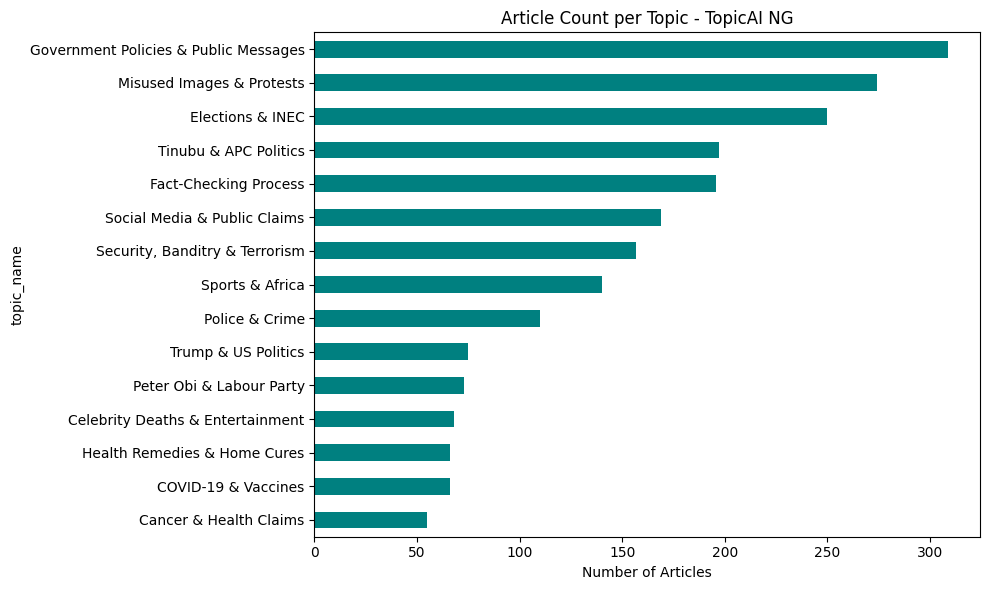

In [10]:
plt.figure(figsize=(10,6))
topic_counts = df['topic_name'].value_counts()
topic_counts.plot(kind='barh', color='teal')
plt.xlabel('Number of Articles')
plt.title('Article Count per Topic - TopicAI NG')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('topic_counts.png', dpi=150)
plt.show()

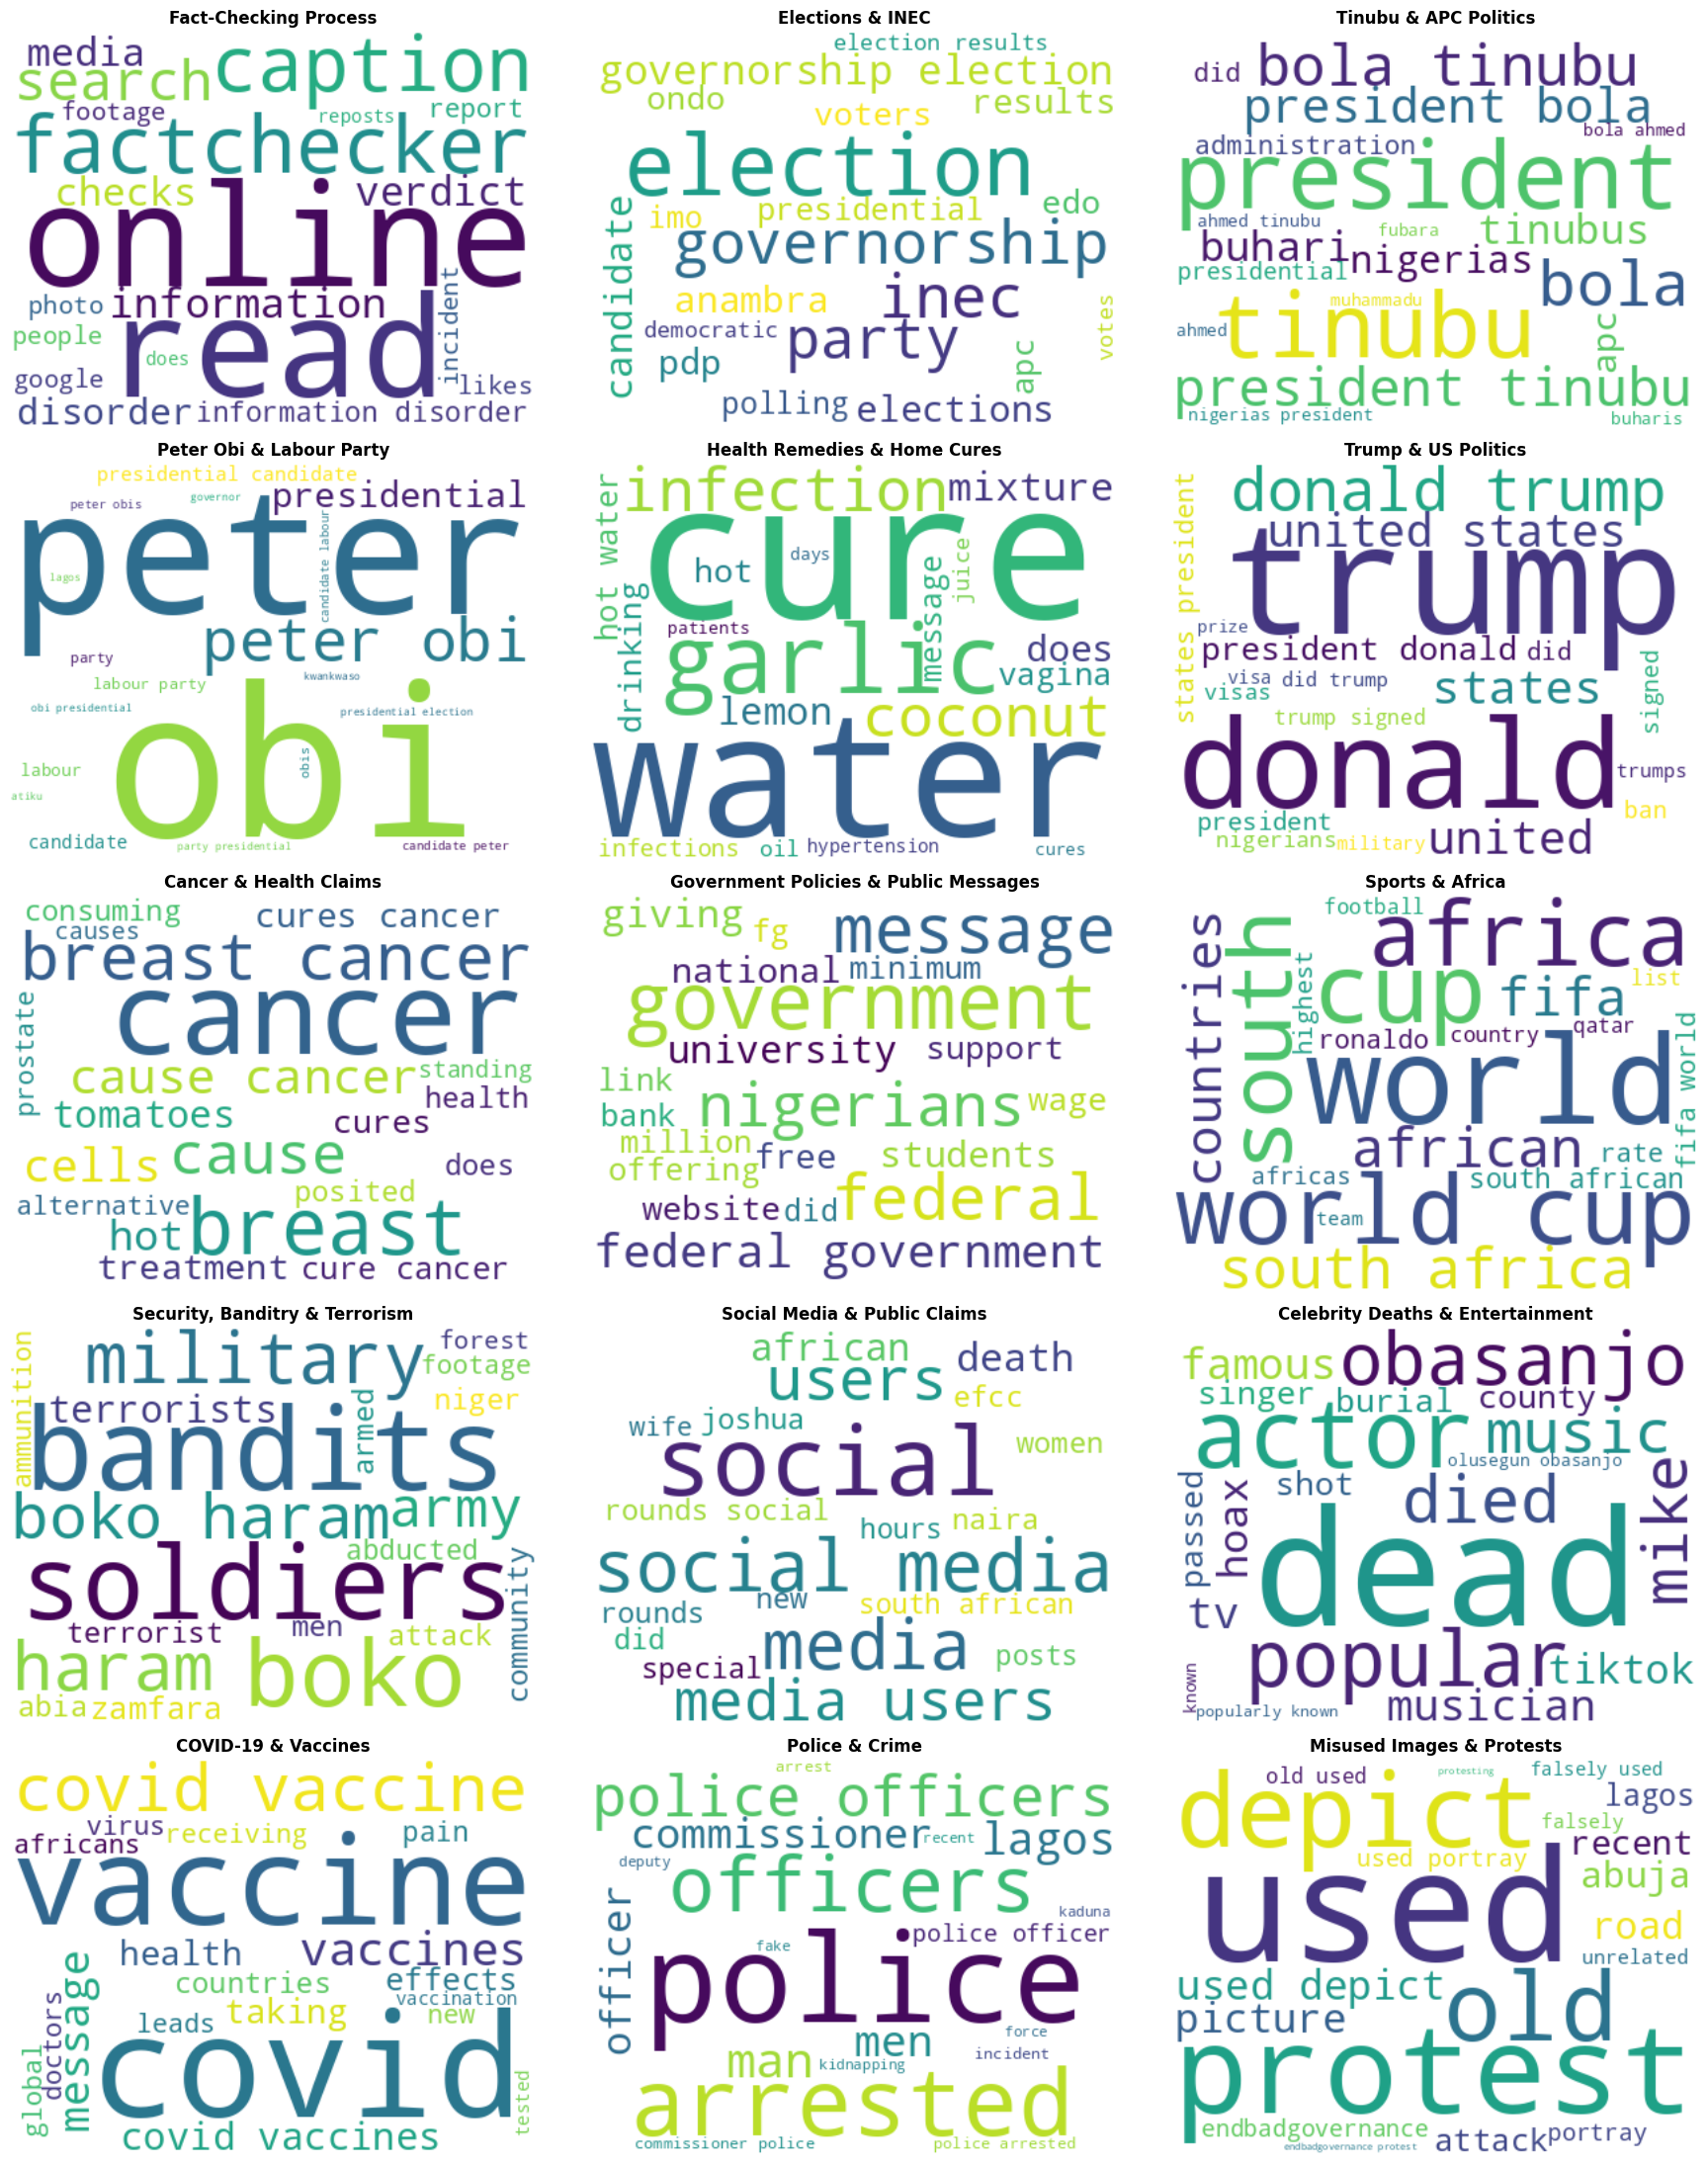

In [11]:
fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()

for topic_idx, topic in enumerate(H):
    word_freq = {feature_names[i]: topic[i] for i in topic.argsort()[:-21:-1]}
    wc = WordCloud(width=400, height=300, background_color='white', colormap='viridis').generate_from_frequencies(word_freq)
    axes[topic_idx].imshow(wc, interpolation='bilinear')
    axes[topic_idx].set_title(topic_names[topic_idx], fontsize=12, fontweight='bold')
    axes[topic_idx].axis('off')

plt.tight_layout()
plt.savefig('topic_wordclouds.png', dpi=150)
plt.show()

In [12]:
import joblib

joblib.dump(nmf_model, 'nmf_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')
joblib.dump(topic_names, 'topic_names.pkl')

print("Model files saved!")

Model files saved!
